In [1]:
import pandas as pd
import numpy as np
import statistics as st
import scipy.stats as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [36]:
#read csv

df = pd.read_csv('/Users/phoo/Desktop/DataSet/Airbnb_Open_Data.csv')
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

# Dulicates

In [38]:
df.duplicated().sum()

np.int64(541)

In [39]:
df.drop_duplicates()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102053,57365208,Cozy bright room near Prospect Park,77326652202,unconfirmed,Mariam,Brooklyn,Flatbush,40.64945,-73.96108,United States,...,NaN,7.0,12.0,3/27/2019,0.44,5.0,1.0,0.0,Shoes off Clean After yourself Turn Lights and...,NaN
102054,57365760,Private Bedroom with Amazing Rooftop View,45936254757,verified,Trey,Brooklyn,Bushwick,40.69872,-73.92718,United States,...,NaN,1.0,19.0,8/31/2017,0.72,3.0,2.0,0.0,#NAME?,NaN
102055,57366313,Pretty Brooklyn One-Bedroom for 2 to 4 people,23801060917,verified,Michael,Brooklyn,Bedford-Stuyvesant,40.67810,-73.90822,United States,...,NaN,2.0,50.0,6/26/2019,3.12,4.0,2.0,235.0,* Check out: 10am * We made an effort to keep ...,NaN
102056,57366865,Room & private bathroom in historic Harlem,15593031571,unconfirmed,Shireen,Manhattan,Harlem,40.81248,-73.94317,United States,...,NaN,2.0,0.0,NaN,NaN,1.0,1.0,0.0,Each of us is working and/or going to school a...,NaN


# Check null

In [40]:
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

# Remove symbols like '$' and ',' then convert (price and service fee)

In [41]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [42]:
df['price'].head()

0    966.0
1    142.0
2    620.0
3    368.0
4    204.0
Name: price, dtype: float64

In [43]:
df['service fee'] = df['service fee'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [44]:
df['service fee'].head()

0    193.0
1     28.0
2    124.0
3     74.0
4     41.0
Name: service fee, dtype: float64

# change datatype and drop and fill columns

In [45]:
df['last review'] = pd.to_datetime(df['last review'])

In [46]:
df.fillna({'last review' : df['last review'].min(), 'reviews per month' : 0, 'review rate number' : 0 }, inplace = True)

In [47]:
df.dropna(subset = ['NAME', 'host name'], inplace=True)

In [48]:
df1 = df.drop(columns=['license', 'house_rules' , 'id', 'host id'], errors='ignore')

In [49]:
df1.isnull().sum()

NAME                                0
host_identity_verified            276
host name                           0
neighbourhood group                26
neighbourhood                      16
lat                                 8
long                                8
country                           526
country code                      122
instant_bookable                   96
cancellation_policy                70
room type                           0
Construction year                 200
price                             239
service fee                       268
minimum nights                    403
number of reviews                 182
last review                         0
reviews per month                   0
review rate number                  0
calculated host listings count    318
availability 365                  420
dtype: int64

In [50]:
df1.describe()

,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,101941.000000,101941.000000,101749.000000,101710.000000,101681.000000,101546.000000,101767.000000,101949,101949.000000,101949.000000,101631.000000,101529.000000
mean,40.728078,-73.949654,2012.486314,625.309950,125.029868,8.123176,27.477768,2018-05-17 08:51:02.801989376,1.162350,3.268830,7.948195,141.252933
min,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,0.000000,1.000000,-10.000000
25%,40.688740,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-31 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,40.722300,-73.954440,2012.000000,624.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,97.000000
75%,40.762740,-73.932340,2017.000000,913.000000,183.000000,5.000000,30.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,0.055854,0.049495,5.764896,331.605927,66.312772,30.315751,49.486565,NaN,1.682444,1.295764,32.281160,135.423732


# Visualization

# What is the distribution of listing prices?

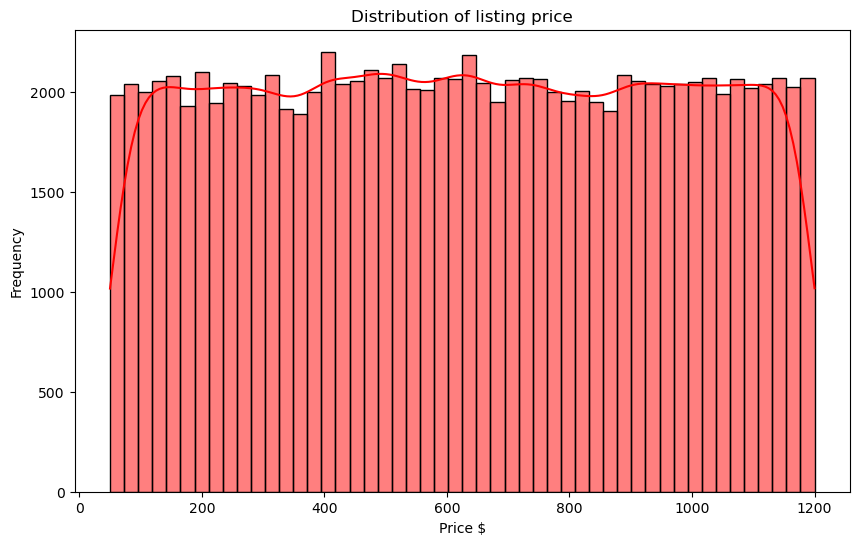

In [77]:
plt.figure(figsize=(10,6))
sns.histplot(df1['price'], bins=50, kde=True, color='red')
plt.title('Distribution of listing price')
plt.xlabel('Price $')
plt.ylabel('Frequency')
plt.show()

In [ ]:
The graph shows an fairly even distribution of listing prices across 
all differnet price ranges, indicating no particular concentration of listings
in any specific price range. 
The KDE line helps visualize this even spread more clearly, confirming that
the dataset contains listings with a wide variety of prices.

# How are different room type distributed?

In [53]:
df['room type'].value_counts()

room type
Entire home/apt    53402
Private room       46217
Shared room         2214
Hotel room           116
Name: count, dtype: int64

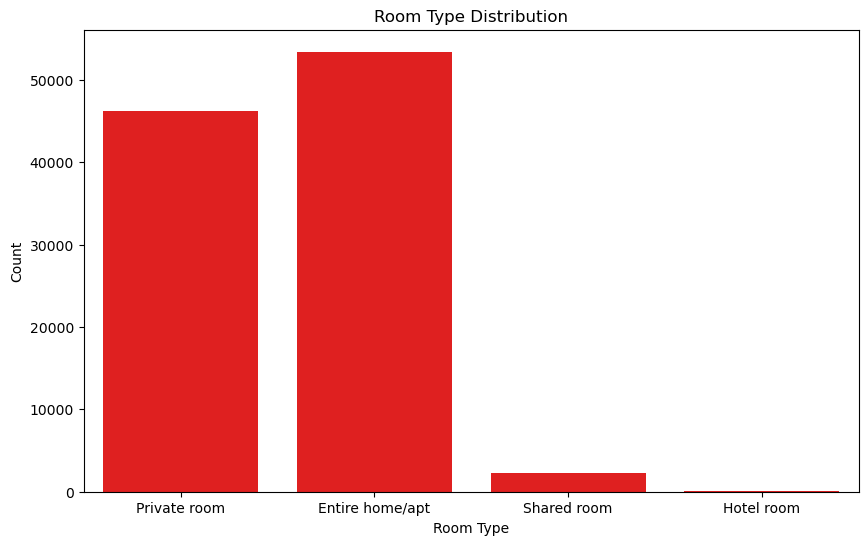

In [76]:
plt.figure(figsize = (10,6))
sns.countplot(x='room type', data=df1, color='red')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

# How are listings distributed across different neighborhoods?

In [55]:
df1['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43512
Brooklyn         41574
Queens           13190
Bronx             2696
Staten Island      949
brookln              1
manhatan             1
Name: count, dtype: int64

In [71]:
df1['neighbourhood group'] = df1['neighbourhood group'].replace({'brookln':'Brooklyn', 'manhatan':'Manhattan'})

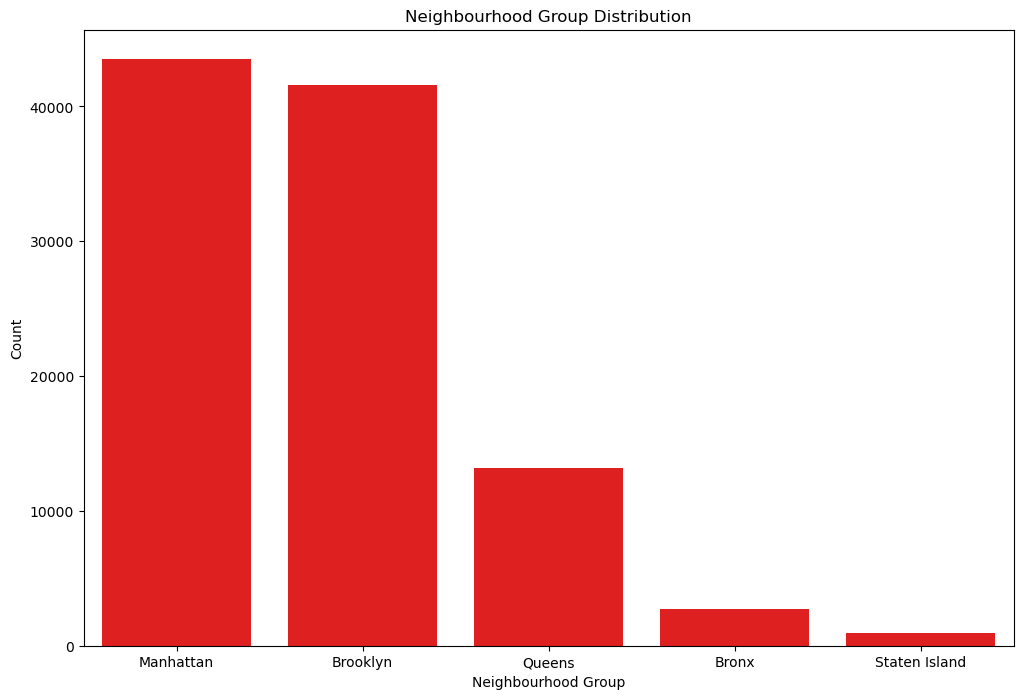

In [73]:
plt.figure(figsize=(12,8))
sns.countplot(x='neighbourhood group', data = df, color='red', order=df1['neighbourhood group'].value_counts().index)
plt.title('Neighbourhood Group Distribution')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.show()

In [ ]:
There are a lot of housing lists in Manhattan neighbourhood group
whereas there are a few options in Staten Island.

# What is the relationship between price and room type?

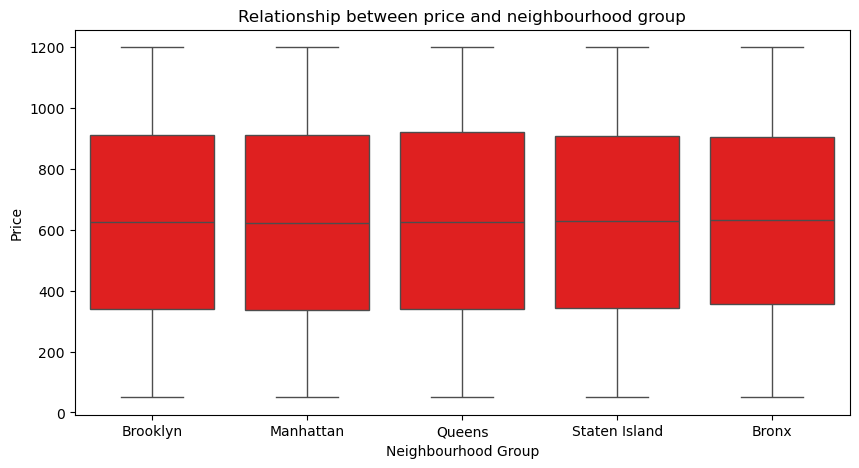

In [109]:
plt.figure(figsize = (10,5))
sns.boxplot(x='neighbourhood group', y='price', data = df1, color = 'red')
plt.title('Relationship between price and neighbourhood group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Price')
plt.show()

In [ ]:
The houses has the similar price ranges across different neighbourhood group.

# What is the relationship between price and room type?

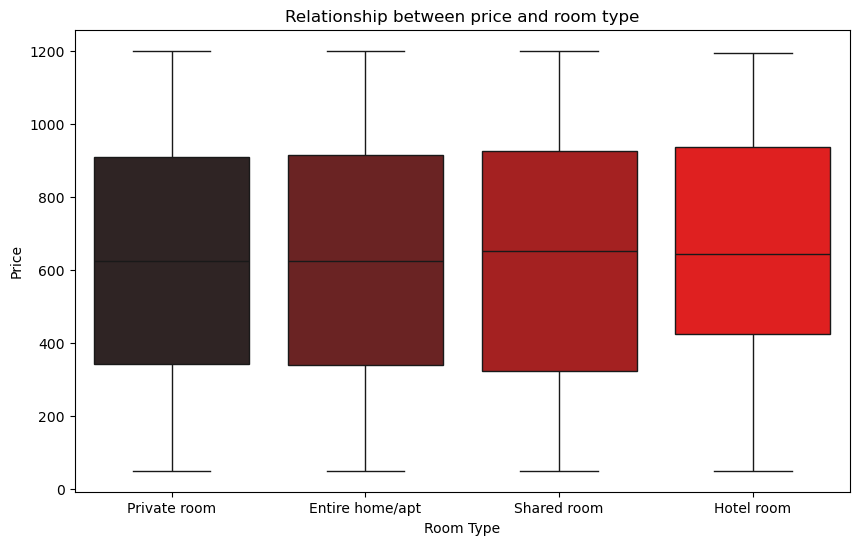

In [78]:
plt.figure(figsize=(10,6))
sns.boxplot(x='room type', y='price', hue='room type', data = df1, color='red')
plt.title('Relationship between price and room type')
plt.xlabel('Room Type')
plt.ylabel('Price')
plt.show()

# How has the number of reviews changed over time?

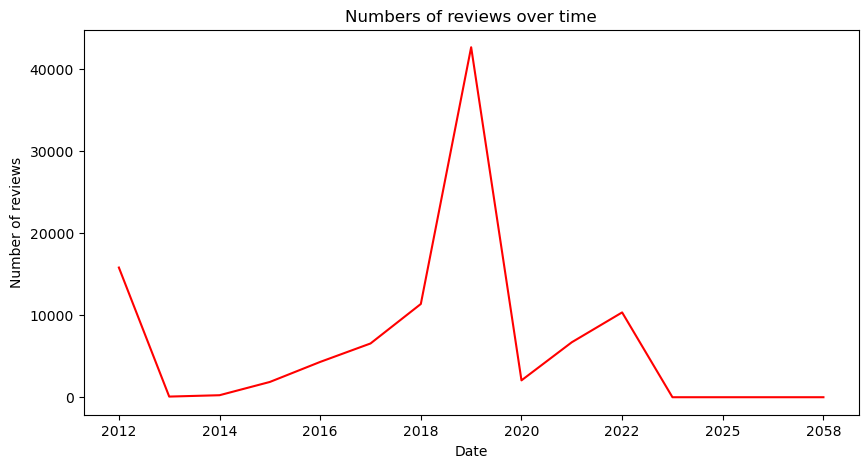

In [96]:
reviews_over_time = df.groupby(df['last review'].dt.strftime('%Y')).size()


plt.figure(figsize=(10,5))
reviews_over_time.plot(kind='line', color='red')
plt.title('Numbers of reviews over time')
plt.xlabel('Date')
plt.ylabel('Number of reviews')
plt.show()

In [ ]:
More than 40,000 reviews were received in 2019